# Stage 1: Data Ingestion

## Goal

Raw CSV files are often too large for standard pandas loading. A 3GB CSV can consume 10GB+ RAM when loaded entirely.

**Our Strategy:**
- Stream the CSV in chunks (100K rows at a time)
- Cast columns to memory-efficient dtypes during ingestion
- Persist result to Parquet format

**Why Parquet?**
- Compresses data by column (reduces 3GB CSV to ~500MB)
- Uses dictionary encoding for strings
- Loads only needed columns, not entire file
- Supports efficient filtering at storage layer

**Output:** `.parquet` file at `data/parquet/train.parquet` ready for Stage 2

## Step 1: Import Libraries and Configure Logging

**Libraries:**
- `pandas`: DataFrames and data manipulation
- `pyarrow`: Parquet serialization engine
- `os`: File path and directory operations
- `logging`: Track progress during chunk-by-chunk ingestion
- `warnings`: Suppress pandas future warnings

Logging is critical: ingestion takes 5-10 minutes. Logging every 10 chunks proves the script is still running.

In [1]:
import pandas as pd
import os
import logging
import warnings

# Suppress non-critical warnings for cleaner output
warnings.filterwarnings('ignore')

# Configure logging to track ingestion progress
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

print('✓ Libraries imported successfully')

✓ Libraries imported successfully


## Step 2: Define Paths and Output Directory

We use absolute paths to work from any directory. The input CSV is in `data/raw/` and output Parquet goes to `data/parquet/`.

In [2]:
from pathlib import Path

# ROBUST PATH RESOLUTION: Works from any directory
# The notebook is in notebooks/ so go one level up to reach project root
PROJECT_ROOT = Path.cwd().parent

# Build absolute paths
RAW_CSV_PATH = PROJECT_ROOT / 'data' / 'raw' / 'train_ver2.csv'
PARQUET_OUTPUT_PATH = PROJECT_ROOT / 'data' / 'parquet' / 'train.parquet'

# Create output directory if it does not exist
PARQUET_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

# Chunk size for streaming (100K rows at a time)
CHUNK_SIZE = 100000

# Verify CSV exists before proceeding
assert RAW_CSV_PATH.exists(), f"CSV file not found at: {RAW_CSV_PATH}"

print(f'Project root: {PROJECT_ROOT}')
print(f'Input CSV: {RAW_CSV_PATH}')
print(f'CSV exists: {RAW_CSV_PATH.exists()}')
print(f'Output Parquet: {PARQUET_OUTPUT_PATH}')
print(f'Chunk size: {CHUNK_SIZE:,} rows')

Project root: /Users/mac/Documents/santander-recommender
Input CSV: /Users/mac/Documents/santander-recommender/data/raw/train_ver2.csv
CSV exists: True
Output Parquet: /Users/mac/Documents/santander-recommender/data/parquet/train.parquet
Chunk size: 100,000 rows


## Step 3: Define Product Columns and Feature Dtypes

24 product columns are binary indicators (0/1) of whether a customer owns each product. Feature columns are cast to memory-efficient dtypes during ingestion.

In [3]:
# 24 Product columns - binary indicators (0/1) for each Santander product
PRODUCT_COLS = [
    'ind_ahor_fin_ult1',      # Savings account
    'ind_aval_fin_ult1',      # Avalista
    'ind_cco_fin_ult1',       # Checking account
    'ind_cder_fin_ult1',      # Credit card
    'ind_cno_fin_ult1',       # Loan
    'ind_ctju_fin_ult1',      # Junior account
    'ind_ctma_fin_ult1',      # Plus account
    'ind_ctop_fin_ult1',      # Optimal account
    'ind_ctpp_fin_ult1',      # Premium account
    'ind_deco_fin_ult1',      # Debit card
    'ind_deme_fin_ult1',      # Demographic details requested
    'ind_dela_fin_ult1',      # Delegated account
    'ind_ecue_fin_ult1',      # E-account
    'ind_fond_fin_ult1',      # Mutual fund
    'ind_hip_fin_ult1',       # Home loan
    'ind_plan_fin_ult1',      # Pension plan
    'ind_pres_fin_ult1',      # Mortgage
    'ind_reca_fin_ult1',      # Payment facility
    'ind_tjcr_fin_ult1',      # Credit card
    'ind_valo_fin_ult1',      # Securities account
    'ind_viv_fin_ult1',       # Home insurance
    'ind_nomina_ult1',        # Payroll account
    'ind_nom_pens_ult1',      # Pension transfer
    'ind_recibo_ult1'         # Direct debit
]

# Customer feature columns with efficient string dtypes
FEATURE_DTYPES = {
    'ncodpers': 'int32',           # Customer ID
    'ind_empleado': 'str',          # Employee flag
    'pais_residencia': 'str',       # Country of residence
    'sexo': 'str',                  # Gender
    'age': 'str',                   # Age
    'fecha_alta': 'str',            # Date of account opening
    'ind_nuevo': 'str',             # New customer flag
    'antiguedad': 'str',            # Seniority (months as customer)
    'indrel': 'str',                # Customer relation type
    'ult_fec_cli_1t': 'str',        # Last date of primary account activity
    'indrel_1mes': 'str',           # Customer relation type (1 month ago)
    'tiprel_1mes': 'str',           # Type of relationship (1 month ago)
    'indresi': 'str',               # Residence flag
    'indext': 'str',                # Foreigner flag
    'conyuemp': 'str',              # Spouse employee flag
    'canal_entrada': 'str',         # Entry channel
    'indfall': 'str',               # Fallen customer indicator
    'tipodom': 'str',               # Address type
    'cod_prov': 'str',              # Province code
    'nomprov': 'str',               # Province name
    'ind_actividad_cliente': 'str', # Activity indicator
    'renta': 'str',                 # Income
    'segmento': 'str'               # Customer segment
}

print(f'✓ {len(PRODUCT_COLS)} product columns defined')
print(f'✓ {len(FEATURE_DTYPES)} feature columns with dtypes defined')

✓ 24 product columns defined
✓ 23 feature columns with dtypes defined


## Step 4: Stream CSV and Convert to Parquet

We iterate through chunks of 100K rows, applying dtype conversions and logging progress every 10 chunks.

In [4]:
# Check if Parquet already exists to avoid re-ingesting
if os.path.exists(PARQUET_OUTPUT_PATH):
    logging.info(f'Parquet file already exists at {PARQUET_OUTPUT_PATH}, loading directly...')
    df = pd.read_parquet(PARQUET_OUTPUT_PATH, engine='pyarrow')
else:
    logging.info(f'Starting CSV ingestion from {RAW_CSV_PATH}...')
    
    # Create a reader object that yields chunks of CHUNK_SIZE rows
    reader = pd.read_csv(
        str(RAW_CSV_PATH),
        chunksize=CHUNK_SIZE,
        dtype=FEATURE_DTYPES
    )
    
    chunks = []  # List to store each chunk
    chunk_num = 0
    
    # Iterate through chunks
    for chunk in reader:
        chunk_num += 1
        
        # Cast fecha_dato to datetime (more efficient than string)
        chunk['fecha_dato'] = pd.to_datetime(chunk['fecha_dato'], format='%Y-%m-%d')
        
        # Cast product columns to Int8 (binary 0/1 values, nullable)
        for col in PRODUCT_COLS:
            chunk[col] = chunk[col].astype('Int8')
        
        chunks.append(chunk)
        
        # Log progress every 10 chunks
        if chunk_num % 10 == 0:
            cumulative_rows = chunk_num * CHUNK_SIZE
            logging.info(f'Chunk {chunk_num}: {cumulative_rows:,} rows processed')
    
    # Concatenate all chunks into a single dataframe
    logging.info('Concatenating all chunks...')
    df = pd.concat(chunks, ignore_index=True)
    
    # Write to Parquet with compression
    logging.info(f'Writing to Parquet: {PARQUET_OUTPUT_PATH}')
    df.to_parquet(str(PARQUET_OUTPUT_PATH), engine='pyarrow', compression='snappy')
    
    logging.info(f'✓ Ingestion complete. DataFrame shape: {df.shape}')

2026-05-20 11:34:21,789 - INFO - Parquet file already exists at /Users/mac/Documents/santander-recommender/data/parquet/train.parquet, loading directly...


## Step 5: Validate the Ingested Data

Display the dataframe shape, dtypes, and sample rows to confirm ingestion was successful.

In [5]:
# Display dataframe shape
print('Dataframe Shape:')
print(f'  {df.shape[0]:,} rows × {df.shape[1]} columns\n')

# Display all dtypes
print('Data Types:')
print(df.dtypes)
print()

# Confirm fecha_dato is datetime
print('Unique dates (sample):')
print(sorted(df['fecha_dato'].unique())[:5])
print()

# Confirm product columns are Int8
print('Product column dtypes (sample):')
print(df[PRODUCT_COLS[:5]].dtypes)
print()

# Display first 3 rows
print('First 3 rows:')
df.head(3)

Dataframe Shape:
  13,647,309 rows × 48 columns

Data Types:
fecha_dato               datetime64[ns]
ncodpers                          int32
ind_empleado                     object
pais_residencia                  object
sexo                             object
age                              object
fecha_alta                       object
ind_nuevo                        object
antiguedad                       object
indrel                           object
ult_fec_cli_1t                   object
indrel_1mes                      object
tiprel_1mes                      object
indresi                          object
indext                           object
conyuemp                         object
canal_entrada                    object
indfall                          object
tipodom                          object
cod_prov                         object
nomprov                          object
ind_actividad_cliente            object
renta                            object
segmento           

,fecha_dato,ncodpers,ind_empleado,pais_residencia,sexo,age,fecha_alta,ind_nuevo,antiguedad,indrel,...,ind_hip_fin_ult1,ind_plan_fin_ult1,ind_pres_fin_ult1,ind_reca_fin_ult1,ind_tjcr_fin_ult1,ind_valo_fin_ult1,ind_viv_fin_ult1,ind_nomina_ult1,ind_nom_pens_ult1,ind_recibo_ult1
0,2015-01-28,1375586,N,ES,H,35,2015-01-12,0,6,1,...,0,0,0,0,0,0,0,0,0,0
1,2015-01-28,1050611,N,ES,V,23,2012-08-10,0,35,1,...,0,0,0,0,0,0,0,0,0,0
2,2015-01-28,1050612,N,ES,V,23,2012-08-10,0,35,1,...,0,0,0,0,0,0,0,0,0,0


## Step 6: Memory Usage Report

Show memory efficiency gains from dtype optimization.

In [6]:
# Calculate memory usage
memory_mb = df.memory_usage(deep=True).sum() / 1024**2
parquet_size_mb = os.path.getsize(PARQUET_OUTPUT_PATH) / 1024**2

print('='*60)
print('Memory Usage Report')
print('='*60)
print(f'DataFrame in memory: {memory_mb:.2f} MB')
print(f'Parquet file on disk: {parquet_size_mb:.2f} MB')
print(f'Compression ratio: {memory_mb/parquet_size_mb:.2f}x')
print('='*60)
print(f'✓ Stage 1 Complete!')
print(f'✓ Parquet file saved to: {PARQUET_OUTPUT_PATH}')
print(f'✓ Ready for Stage 2: Cohort Selection')
print('='*60)

Memory Usage Report
DataFrame in memory: 17104.15 MB
Parquet file on disk: 228.99 MB
Compression ratio: 74.69x
✓ Stage 1 Complete!
✓ Parquet file saved to: /Users/mac/Documents/santander-recommender/data/parquet/train.parquet
✓ Ready for Stage 2: Cohort Selection


## Step 7: Data Distribution Plots

These plots give us a **visual understanding of the raw dataset** before any filtering or processing:
- Spotting skewed distributions or missing data early prevents surprises in later stages
- Helps identify data quality issues before building features
- Provides baselines for comparison after Stage 2 filtering

We will create **3 plots**:
1. Monthly record distribution (how data spans time)
2. Product ownership rates (which products are popular)
3. Customer age distribution (customer demographics)

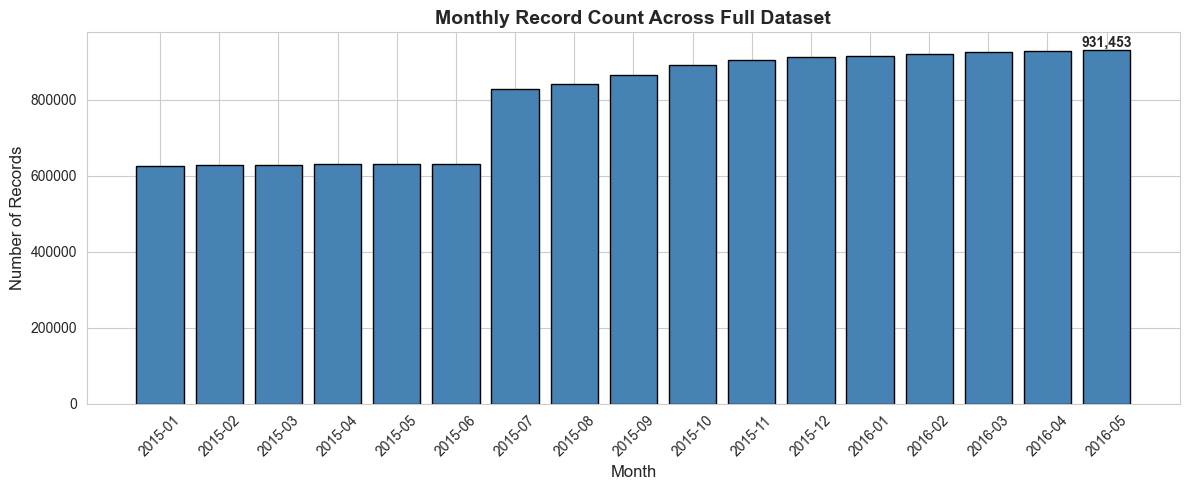


✓ Plot 1 complete: 17 months, 13,647,309 total records


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plotting style and size
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# PLOT 1: Monthly Record Distribution
# Shows how many rows exist per month - reveals temporal balance in dataset
monthly_counts = df['fecha_dato'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(monthly_counts)), monthly_counts.values, color='steelblue', edgecolor='black')

# Find the tallest bar and annotate its count
max_idx = monthly_counts.values.argmax()
max_height = monthly_counts.values[max_idx]
ax.text(max_idx, max_height, f'{int(max_height):,}', ha='center', va='bottom', fontweight='bold')

# Labels and formatting
ax.set_xticks(range(len(monthly_counts)))
ax.set_xticklabels([d.strftime('%Y-%m') for d in monthly_counts.index], rotation=45)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Records', fontsize=12)
ax.set_title('Monthly Record Count Across Full Dataset', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\n✓ Plot 1 complete: {len(monthly_counts)} months, {monthly_counts.sum():,} total records')

## Product Ownership Heatmap

This plot shows the **average ownership rate** of each product across all customers:
- Ownership rate = mean of product column (0 = nobody owns it, 1 = everyone owns it)
- Products with very low ownership rates are **harder to predict** (fewer positive examples)
- This helps us identify imbalanced product predictions and plan data strategies

Expect a horizontal bar chart with rates between 0 and 1.

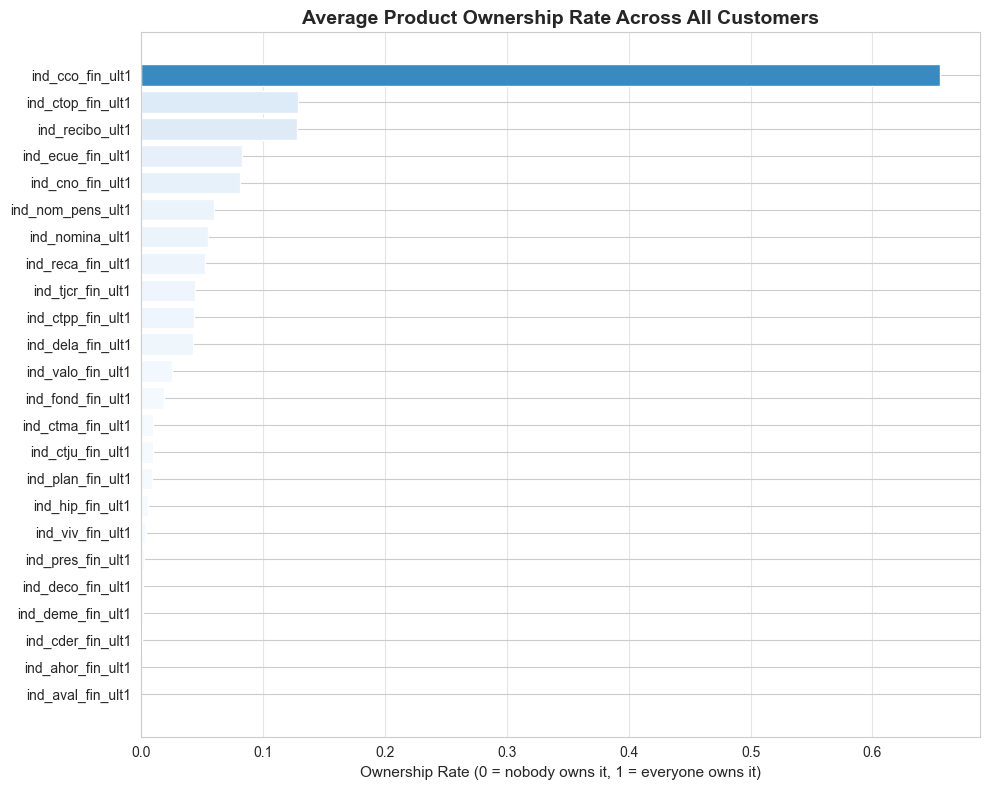


✓ Plot 2 complete: Product ownership rates
  Most popular: ind_cco_fin_ult1 (65.5%)
  Least popular: ind_aval_fin_ult1 (0.0%)


In [8]:
# PLOT 2: Product Ownership Rates
# Calculate the average ownership rate per product across all customers
product_ownership = df[PRODUCT_COLS].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(product_ownership)), product_ownership.values, color=plt.cm.Blues(product_ownership.values))

# Labels and formatting
ax.set_yticks(range(len(product_ownership)))
ax.set_yticklabels(product_ownership.index)
ax.set_xlabel('Ownership Rate (0 = nobody owns it, 1 = everyone owns it)', fontsize=11)
ax.set_title('Average Product Ownership Rate Across All Customers', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.5)

plt.tight_layout()
plt.show()

print(f'\n✓ Plot 2 complete: Product ownership rates')
print(f'  Most popular: {product_ownership.index[-1]} ({product_ownership.values[-1]:.1%})')
print(f'  Least popular: {product_ownership.index[0]} ({product_ownership.values[0]:.1%})')

## Customer Age Distribution

Age is one of the **most predictive customer features** for product recommendations:
- Different age groups prefer different products
- We cast age to numeric here for plotting only — actual cleaning happens in Stage 4
- We expect a **roughly normal distribution centered around 40-50**

This plot helps identify if our customer base skews young, old, or is well-distributed.

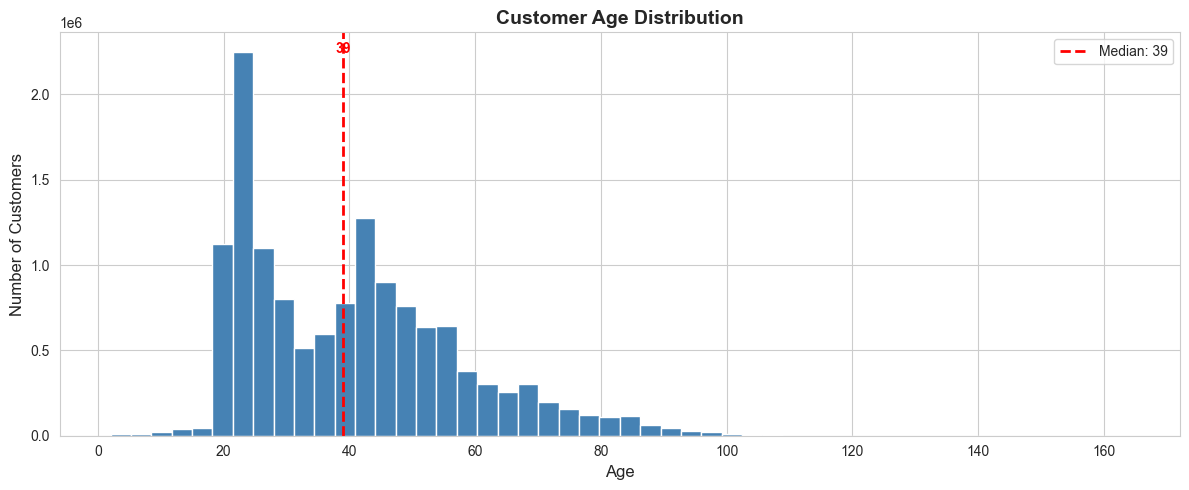


✓ Plot 3 complete: Customer age distribution
  Median age: 39
  Mean age: 40
  Age range: 2 - 164
  Missing ages: 27,734


In [9]:
# PLOT 3: Customer Age Distribution
# Cast age to numeric (some may be strings or NaN from raw CSV)
age_numeric = pd.to_numeric(df['age'], errors='coerce')
age_clean = age_numeric.dropna()  # Remove NaN for plotting only

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(age_clean, bins=50, color='steelblue', edgecolor='white')

# Add median line and annotation
median_age = age_clean.median()
ax.axvline(median_age, color='red', linestyle='--', linewidth=2, label=f'Median: {median_age:.0f}')
ax.text(median_age, ax.get_ylim()[1] * 0.95, f'{median_age:.0f}', 
        ha='center', fontweight='bold', color='red')

# Labels and formatting
ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.set_title('Customer Age Distribution', fontsize=14, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

print(f'\n✓ Plot 3 complete: Customer age distribution')
print(f'  Median age: {median_age:.0f}')
print(f'  Mean age: {age_clean.mean():.0f}')
print(f'  Age range: {age_clean.min():.0f} - {age_clean.max():.0f}')
print(f'  Missing ages: {age_numeric.isna().sum():,}')